# <center>$~~~~~$Research on Quantitative Stock Selection and Effect Evaluation Based on Machine Learning$~~~~~$</center>

### $~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$ By Group 16

$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$胡万妮  2130018019
$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$艾子为  2130018001
$~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~$蒙蕙煊  2130018043

# <center> Overall Strategy </center>

## Research Purpose
The purpose of this research is to utilize the data of the constituents of the CSI 500 Index from August 16, 2024, to November 29, 2024, to predict the future direction of stock prices using machine learning models and to construct quantitative stock selection strategies based on these models. The specific research content includes:

1. **Model Prediction Capability Comparison**: Comparing the predictive capabilities of four different machine learning models in forecasting the future direction of stock price movements.
2. **Quantitative Stock Selection Strategy Analysis**: Analyzing the performance of quantitative stock selection strategies constructed based on the aforementioned machine learning models under different models.

#### Data Usage Specification
- **Model Training and Hyperparameter Tuning**: Data from August 16, 2024, to November 1, 2024, is used for training machine learning models and adjusting hyperparameters.
- **Quantitative Strategy Backtesting**: Data from November 2, 2024, to November 29, 2024, is used for backtesting the quantitative stock selection strategies.


## Research approach
The methodology of this study includes the following steps:

1. **Data Acquisition**
   First, we obtained data for all constituents of the CSI 500 Index from the Wind database, covering the period from August 16, 2024, to November 29, 2024, which includes 15 indicators (7 technical indicators and 8 financial indicators). The data was labeled based on the future one-week return and price movement of these stocks and then preprocessed.

2. **Feature Dimensionality Reduction**
   We applied Principal Component Analysis (PCA) to reduce the dimensionality of the data, calculated the interpretable variance of each principal component, and determined the number of principal components to retain based on the required cumulative interpretable variance.

3. **Model Prediction and Evaluation**
   The dimensionality-reduced data was used to train four machine learning algorithm models. Hyperparameter tuning of the models was conducted using methods such as grid search, and the trained models were evaluated using multiple evaluation metrics.

4. **Quantitative Strategy Construction**
   The well-trained machine learning models were utilized to construct quantitative stock selection strategies.

5. **Backtesting Results Analysis**
   Backtesting was performed using data from November 2, 2024, to November 29, 2024, and the results were compared and analyzed.


# <center> Code Implementation </center>

### Import Module

In [1]:
import pandas as pd
import tushare as ts
import numpy as np
import datetime
import time
import talib as tb
import matplotlib.pyplot as plt 
import talib as ta

## 1 Data Acquisition

### 1.1 Selecting Stocks from the CSI 500 index

#### Stock Data from CSI 500 index

In [2]:
ts.set_token(os.getenv('TUSHARE_TOKEN'))
pro=ts.pro_api()

In [3]:
# stocks from CSI 500 index
data_CSI = pro.index_weight(index_code='000905.SH', start_date='20241129', end_date='20241130')
data_CSI.head()

,index_code,con_code,trade_date,weight
0,000905.SH,300502.SZ,20241129,1.161
1,000905.SH,600418.SH,20241129,0.873
2,000905.SH,002625.SZ,20241129,0.861
3,000905.SH,002028.SZ,20241129,0.683
4,000905.SH,600839.SH,20241129,0.568


In [4]:
# A shares data
A_shares_data = pro.query('stock_basic', exchange='', fields='ts_code,symbol,name,area,industry,list_date')
A_shares_data

,ts_code,symbol,name,area,industry,list_date
0,000001.SZ,000001,平安银行,深圳,银行,19910403
1,000002.SZ,000002,万科A,深圳,全国地产,19910129
2,000004.SZ,000004,国华网安,深圳,软件服务,19910114
3,000006.SZ,000006,深振业A,深圳,区域地产,19920427
4,000007.SZ,000007,全新好,深圳,其他商业,19920413
...,...,...,...,...,...,...
5372,920099.BJ,920099,瑞华技术,None,None,20240925
5373,920111.BJ,920111,聚星科技,None,None,20241111
5374,920118.BJ,920118,太湖远大,None,None,20240822
5375,920128.BJ,920128,胜业电气,None,None,20241129


In [5]:
# together
data_CSI.rename(columns={'con_code': 'ts_code'}, inplace=True)
data = pd.merge(A_shares_data, data_CSI, on='ts_code', how='inner')
data.drop(columns=['index_code','trade_date','weight'], inplace=True)

In [6]:
data

,ts_code,symbol,name,area,industry,list_date
0,000009.SZ,000009,中国宝安,深圳,电气设备,19910625
1,000021.SZ,000021,深科技,深圳,元器件,19940202
2,000027.SZ,000027,深圳能源,深圳,火力发电,19930903
3,000031.SZ,000031,大悦城,深圳,全国地产,19931008
4,000032.SZ,000032,深桑达A,深圳,建筑工程,19931028
...,...,...,...,...,...,...
495,688777.SH,688777,中控技术,浙江,专用机械,20201124
496,688778.SH,688778,厦钨新能,福建,电气设备,20210805
497,688779.SH,688779,五矿新能,湖南,电气设备,20210811
498,688819.SH,688819,天能股份,浙江,电气设备,20210118


#### Screening stocks

 Selection condition  
- Remove ST stocks 
- Remove GEM stocks 
- Remove stocks that have been on the market for less than two years   
- Remove suspended stocks

In [7]:
today = '20241130'
lastday = '20241129'
last_year = '20231130'
last_2year = '20221130'
Lastweek = '20241124'
last_mon = '20241030'

In [8]:
# Remove ST stocks
st_data = data[data.name.str.contains('ST')]    
sts = st_data['name'].values.tolist() 
for st in sts:
    data = data.drop(index=(data.loc[(data['name'] == st)].index))

# Remove GEM stocks
cy_data = data[data.ts_code.str.contains('^30')]  
cys = cy_data['ts_code'].values.tolist()  
for cy in cys:
    data = data.drop(index=(data.loc[(data['ts_code'] == cy)].index))

# Remove Stocks that have been on the market for less than two years
data = data[data['list_date']<last_2year]

# Remove suspended stocks
tp_df = pro.suspend_d(suspend_type = 'S', trade_date = today)
tp_list = tp_df['ts_code'].values.tolist()
for tp in tp_list:
    data = data.drop(index=(data.loc[(data['ts_code'] == tp)].index))

# data_first_sel
data_first_sel = data
# reset index
data_first_sel.reset_index(drop=True, inplace=True)
data_first_sel.index = range(1, len(data) + 1)

In [9]:
data_first_sel.head()

,ts_code,symbol,name,area,industry,list_date
1,000009.SZ,000009,中国宝安,深圳,电气设备,19910625
2,000021.SZ,000021,深科技,深圳,元器件,19940202
3,000027.SZ,000027,深圳能源,深圳,火力发电,19930903
4,000031.SZ,000031,大悦城,深圳,全国地产,19931008
5,000032.SZ,000032,深桑达A,深圳,建筑工程,19931028


In [10]:
# Selected stock codes are stored in list：stock_selected_code
stock_selected_code = data_first_sel['ts_code'].values.tolist()

### 1.2 Import Data.xlsx File

**Data Contained in the File**

- **Factor Selection**: In most quantitative investment studies, one or more indicators are typically used to construct investment strategies, which generally include volume-price indicators and financial indicators. This paper selects indicators in two major categories: technical indicators and financial indicators. Stock prices essentially reflect the intrinsic value of a company, and financial indicators can to some extent reflect the operating conditions of a company. For technical indicators, commonly used indicators such as MACD, RSI, and OBV have been chosen.

    - **Financial Indicators**: T_MV (Total Market Value), PE (Price-to-Earnings Ratio), PB (Price-to-Book Ratio), EPS (Earnings Per Share), ROE (Return on Equity), Net_profit (Net Profit), Operation_revenue (Operating Revenue), TA_turnover (Total Asset Turnover).
    
    - **Technical Indicators**: MACD (Moving Average Convergence/Divergence), RSI (Relative Strength Index), OBV (On-Balance Volume), CCI (Commodity Channel Index), ATR (Average True Range), WR (Williams %R), MI (Momentum Indicator).

- **Other Data**

    - ts_code: Stock code
    - Name: Stock name
    - Chage_W: Weekly price change percentage

- **Data Source**: Wind database


In [11]:
Index_data = pd.read_excel("data_from_wind.xlsx")

In [12]:
Index_data.head()

,ts_code,Name,T_MV,PE,PB,EPS,ROE,Net_profit,Operation_revenue,TA_turnover,MACD,RSI,OBV,CCI,ATR,WR,MI,Chage_W
0,000009.SZ,中国宝安,2.032421e+10,34.5717,2.0470,0.2933,7.9352,1.490655e+09,2.746837e+10,0.5998,-0.1297,35.3324,2.656871e+08,-143.4724,0.16,90.5405,-0.26,-5.3299
1,000021.SZ,深科技,2.095869e+10,31.4987,1.9394,0.4131,6.0580,8.751065e+08,1.345725e+10,0.5169,-0.3199,42.7333,1.518271e+08,-25.0108,0.19,77.4390,-0.38,-4.6165
2,000027.SZ,深圳能源,3.177936e+10,12.6260,1.0804,0.2700,4.4040,3.215154e+09,4.202143e+10,0.2749,-0.0802,43.1857,1.368246e+08,65.4321,0.11,39.2857,-0.08,-9.5808
3,000031.SZ,大悦城,1.028715e+10,-5.9445,0.7492,-0.3400,-10.0215,-3.083388e+08,3.456520e+10,0.1783,0.0091,50.2568,1.373441e+08,29.4574,0.09,58.3333,0.09,-4.1667
4,000032.SZ,深桑达A,1.456588e+10,36.1197,2.2918,0.2897,5.4673,8.962357e+08,5.873296e+10,1.0293,-0.3631,36.8475,4.534695e+07,-100.2741,0.36,98.0676,-0.35,-3.0469


Use the `fillna` function to replace all missing values with the average value.

In [13]:
print(Index_data.isnull().sum())

ts_code               0
Name                  0
T_MV                  0
PE                    0
PB                    0
EPS                   0
ROE                  16
Net_profit            0
Operation_revenue    16
TA_turnover           0
MACD                  0
RSI                   0
OBV                   0
CCI                   0
ATR                   0
WR                    0
MI                    0
Chage_W               0
dtype: int64


In [14]:
Index_data.fillna(Index_data.mean(), inplace=True)

### 1.3 Merge Index_data with data_first_sel

In [15]:
data = pd.merge(Index_data, data_first_sel, on='ts_code')
data.drop(columns=['symbol','name','area','industry','list_date'], inplace=True)

In [16]:
data

,ts_code,Name,T_MV,PE,PB,EPS,ROE,Net_profit,Operation_revenue,TA_turnover,MACD,RSI,OBV,CCI,ATR,WR,MI,Chage_W
0,000009.SZ,中国宝安,2.032421e+10,34.5717,2.0470,0.2933,7.9352,1.490655e+09,2.746837e+10,0.5998,-0.1297,35.3324,2.656871e+08,-143.4724,0.16,90.5405,-0.26,-5.3299
1,000009.SZ,中国宝安,1.924094e+10,32.7290,1.9379,0.2933,7.9352,1.490655e+09,2.746837e+10,0.5998,-0.2273,25.9329,2.654581e+08,-135.0097,0.14,94.0594,-0.79,1.8767
2,000009.SZ,中国宝安,1.960203e+10,42.5592,1.9743,0.2933,7.9352,1.262337e+09,2.444397e+10,0.5998,-0.2083,38.2054,2.652783e+08,-23.8748,0.22,75.6098,-0.56,1.5789
3,000009.SZ,中国宝安,1.991153e+10,43.2312,1.9954,0.2933,7.9352,1.262337e+09,2.444397e+10,0.5998,-0.1255,46.0188,2.653796e+08,82.0466,0.16,47.1429,-0.17,-3.8860
4,000009.SZ,中国宝安,1.913777e+10,41.5513,1.9179,0.2933,7.9352,1.262337e+09,2.444397e+10,0.5998,-0.1180,37.1684,2.651667e+08,-91.4510,0.26,90.0000,-0.21,-0.1348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6971,689009.SH,九号公司-WD,3.266524e+10,27.4771,5.3932,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,-0.0487,48.3587,3.941749e+06,-82.7562,1.90,65.3402,-3.42,3.1600
6972,689009.SH,九号公司-WD,3.369745e+10,28.3454,5.5625,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,-0.1400,52.9744,4.191906e+06,56.5260,2.90,33.2661,-0.65,1.1274
6973,689009.SH,九号公司-WD,3.407736e+10,28.6649,5.6252,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,0.3717,52.8930,4.360900e+06,77.6533,2.40,33.7931,-0.84,-9.4236
6974,689009.SH,九号公司-WD,3.086603e+10,25.9637,5.0951,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,-0.2940,40.8499,4.220637e+06,-134.1781,2.56,99.8450,-2.36,3.3442


### 1.4 Determine the Flag with Weekly Price Change Data

In [17]:
data['flag'] = data['Chage_W'].apply(lambda x: 1 if x > 0 else 0)

In [18]:
data

,ts_code,Name,T_MV,PE,PB,EPS,ROE,Net_profit,Operation_revenue,TA_turnover,MACD,RSI,OBV,CCI,ATR,WR,MI,Chage_W,flag
0,000009.SZ,中国宝安,2.032421e+10,34.5717,2.0470,0.2933,7.9352,1.490655e+09,2.746837e+10,0.5998,-0.1297,35.3324,2.656871e+08,-143.4724,0.16,90.5405,-0.26,-5.3299,0
1,000009.SZ,中国宝安,1.924094e+10,32.7290,1.9379,0.2933,7.9352,1.490655e+09,2.746837e+10,0.5998,-0.2273,25.9329,2.654581e+08,-135.0097,0.14,94.0594,-0.79,1.8767,1
2,000009.SZ,中国宝安,1.960203e+10,42.5592,1.9743,0.2933,7.9352,1.262337e+09,2.444397e+10,0.5998,-0.2083,38.2054,2.652783e+08,-23.8748,0.22,75.6098,-0.56,1.5789,1
3,000009.SZ,中国宝安,1.991153e+10,43.2312,1.9954,0.2933,7.9352,1.262337e+09,2.444397e+10,0.5998,-0.1255,46.0188,2.653796e+08,82.0466,0.16,47.1429,-0.17,-3.8860,0
4,000009.SZ,中国宝安,1.913777e+10,41.5513,1.9179,0.2933,7.9352,1.262337e+09,2.444397e+10,0.5998,-0.1180,37.1684,2.651667e+08,-91.4510,0.26,90.0000,-0.21,-0.1348,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6971,689009.SH,九号公司-WD,3.266524e+10,27.4771,5.3932,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,-0.0487,48.3587,3.941749e+06,-82.7562,1.90,65.3402,-3.42,3.1600,1
6972,689009.SH,九号公司-WD,3.369745e+10,28.3454,5.5625,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,-0.1400,52.9744,4.191906e+06,56.5260,2.90,33.2661,-0.65,1.1274,1
6973,689009.SH,九号公司-WD,3.407736e+10,28.6649,5.6252,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,0.3717,52.8930,4.360900e+06,77.6533,2.40,33.7931,-0.84,-9.4236,0
6974,689009.SH,九号公司-WD,3.086603e+10,25.9637,5.0951,8.3700,11.5514,1.187529e+09,1.360141e+10,1.0100,-0.2940,40.8499,4.220637e+06,-134.1781,2.56,99.8450,-2.36,3.3442,1


---

## 2. Feature Dimensionality Reduction - Principal Component Analysis (PCA)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

### 2.1 Data Preparation

Extract the data for PCA.

In [20]:
data_pca = data.iloc[:,2:17]
data_pca.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6976 entries, 0 to 6975
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   T_MV               6976 non-null   float64
 1   PE                 6976 non-null   float64
 2   PB                 6976 non-null   float64
 3   EPS                6976 non-null   float64
 4   ROE                6976 non-null   float64
 5   Net_profit         6976 non-null   float64
 6   Operation_revenue  6976 non-null   float64
 7   TA_turnover        6976 non-null   float64
 8   MACD               6976 non-null   float64
 9   RSI                6976 non-null   float64
 10  OBV                6976 non-null   float64
 11  CCI                6976 non-null   float64
 12  ATR                6976 non-null   float64
 13  WR                 6976 non-null   float64
 14  MI                 6976 non-null   float64
dtypes: float64(15)
memory usage: 872.0 KB


In [21]:
X = data_pca

Data normalization.

In [22]:
scaler = StandardScaler()
scaler.fit(X)
X_s = scaler.transform(X)
X_s = pd.DataFrame(X_s, columns=X.columns)

In [23]:
X_s

,T_MV,PE,PB,EPS,ROE,Net_profit,Operation_revenue,TA_turnover,MACD,RSI,OBV,CCI,ATR,WR,MI
0,-0.337505,0.028604,-0.083823,-0.377920,-0.070179,0.150840,0.048615,0.002150,-0.264294,-1.319838,2.736295,-1.319531,-0.417452,1.178299,-0.202516
1,-0.449921,0.024611,-0.122092,-0.377920,-0.070179,0.150840,0.048615,0.002150,-0.330419,-2.008117,2.733210,-1.251138,-0.425875,1.291665,-0.311084
2,-0.412449,0.045914,-0.109324,-0.377920,-0.070179,0.015992,-0.006659,0.002150,-0.317546,-1.109462,2.730788,-0.352983,-0.392182,0.697288,-0.263970
3,-0.380330,0.047370,-0.101923,-0.377920,-0.070179,0.015992,-0.006659,0.002150,-0.261449,-0.537325,2.732153,0.503039,-0.417452,-0.219808,-0.184080
4,-0.460628,0.043730,-0.129107,-0.377920,-0.070179,0.015992,-0.006659,0.002150,-0.256368,-1.185397,2.729285,-0.899111,-0.375336,1.160886,-0.192274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6971,0.943185,0.013230,1.089903,4.405199,0.297538,-0.028190,-0.204820,0.784132,-0.209416,-0.365986,-0.789212,-0.828843,0.315369,0.366440,-0.849827
6972,1.050303,0.015111,1.149288,4.405199,0.297538,-0.028190,-0.204820,0.784132,-0.271273,-0.028000,-0.785842,0.296790,0.736530,-0.666867,-0.282406
6973,1.089728,0.015804,1.171281,4.405199,0.297538,-0.028190,-0.204820,0.784132,0.075407,-0.033961,-0.783566,0.467534,0.525949,-0.649889,-0.321326
6974,0.756472,0.009950,0.985341,4.405199,0.297538,-0.028190,-0.204820,0.784132,-0.375609,-0.915818,-0.785456,-1.244417,0.593335,1.478055,-0.632691


### 2.2 Feature Variable Correlation Analysis

In [24]:
print(X_s.corr(method='pearson'))  

                       T_MV        PE        PB       EPS       ROE  \
T_MV               1.000000  0.040350  0.140983  0.070651  0.088044   
PE                 0.040350  1.000000  0.059399 -0.006094 -0.013364   
PB                 0.140983  0.059399  1.000000  0.133126 -0.014450   
EPS                0.070651 -0.006094  0.133126  1.000000  0.632891   
ROE                0.088044 -0.013364 -0.014450  0.632891  1.000000   
Net_profit         0.446422  0.001373 -0.135594  0.231358  0.447543   
Operation_revenue  0.069129 -0.005110 -0.134513 -0.003310 -0.006848   
TA_turnover       -0.067789 -0.003731  0.002564  0.119419  0.204615   
MACD               0.121854  0.004572  0.136635 -0.048334 -0.019307   
RSI                0.198719  0.009368  0.097737 -0.048101 -0.065311   
OBV                0.186684  0.011513 -0.143480 -0.230023 -0.159847   
CCI                0.111927  0.012766  0.069385 -0.011412 -0.021641   
ATR                0.100277  0.010964  0.295400  0.484022  0.133291   
WR    

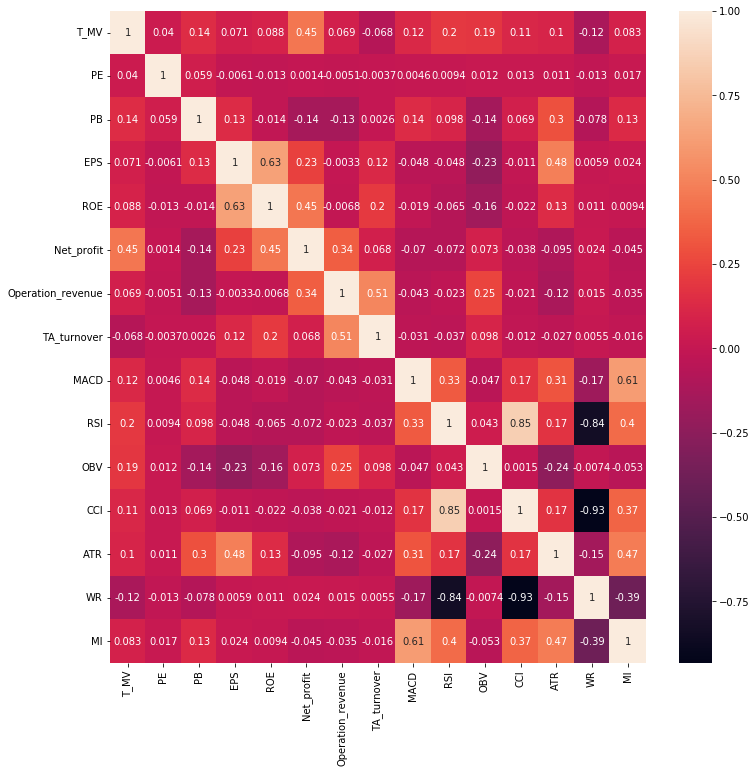

In [25]:
plt.figure(figsize=(12,12))
plt.subplot(1,1,1)
sns.heatmap(X_s.corr(), annot=True)

### 2.3 Performing PCA 

In [26]:
model = PCA()  # Set the model to Principal Component Analysis algorithm
model.fit(X_s)  # Fit the model based on the data in X_s using the fit method
# Set to not display numbers in scientific notation, but show them directly
np.set_printoptions(suppress=True)  

### 2.4 Calculation of Eigenvalues and Variance Contribution Rates

In [27]:
model.explained_variance_ # Eigenvalues

array([3.34370865, 2.20807142, 1.96797434, 1.34199607, 1.29742402,
       1.04720977, 0.93847958, 0.73441131, 0.6325107 , 0.46914488,
       0.38590266, 0.23904537, 0.1911357 , 0.1414547 , 0.06368135])

In [28]:
model.explained_variance_ratio_ # Variance Contribution Rates

array([0.22288196, 0.14718366, 0.13117948, 0.08945358, 0.08648254,
       0.06980398, 0.06255634, 0.04895374, 0.04216134, 0.03127184,
       0.02572316, 0.01593407, 0.01274055, 0.00942896, 0.00424481])

Draw a scree plot.

[3.34370865 2.20807142 1.96797434 1.34199607 1.29742402 1.04720977
 0.93847958 0.73441131 0.6325107  0.46914488 0.38590266 0.23904537
 0.1911357  0.1414547  0.06368135]


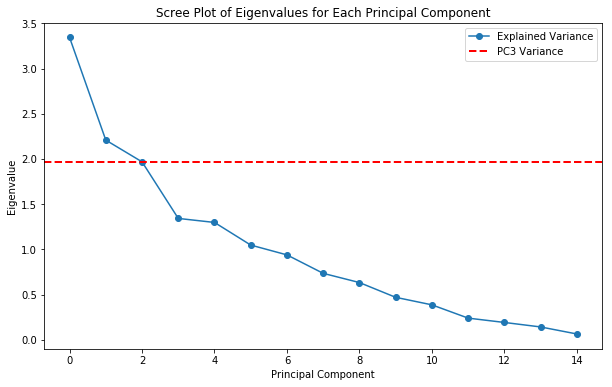

<Figure size 432x288 with 0 Axes>

In [72]:
# Confirm that model.explained_variance_ is a one-dimensional array and print it.
print(model.explained_variance_)

# Plot a scree plot to visualize the eigenvalues of each principal component.
plt.figure(figsize=(10, 6))  # Set the figure size.
plt.plot(model.explained_variance_, 'o-', label='Explained Variance')  # Plot the explained variance.

# Add a red dashed line at the eigenvalue of the third principal component.
plt.axhline(model.explained_variance_[2], color='r', linestyle='--', linewidth=2, label='PC3 Variance')

# Configure the plot to display Chinese characters properly.
plt.rcParams['font.sans-serif'] = ['SimHei']

# Label the x-axis as 'Principal Component' and the y-axis as 'Eigenvalue'.
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')

# Set the plot title to 'Scree Plot of Eigenvalues for Each Principal Component'.
plt.title('Scree Plot of Eigenvalues for Each Principal Component')

# Show the legend.
plt.legend()

# Display the plot.
plt.show()

# Save the plot as a PNG file.
plt.savefig('Scree Plot of Eigenvalues for Each Principal Component.png')

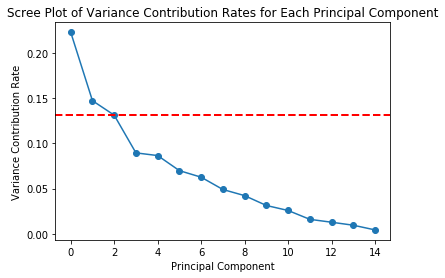

<Figure size 432x288 with 0 Axes>

In [73]:
# Plot the explained variance ratio of each principal component.
plt.plot(model.explained_variance_ratio_, 'o-')

# Add a red dashed line at the variance contribution ratio of the third principal component.
plt.axhline(model.explained_variance_ratio_[2], color='r', linestyle='--', linewidth=2)

# Label the x-axis as 'Principal Component' and the y-axis as 'Variance Contribution Rate'.
plt.xlabel('Principal Component')
plt.ylabel('Variance Contribution Rate')

# Set the title of the plot to 'Scree Plot of Variance Contribution Rates for Each Principal Component'.
plt.title('Scree Plot of Variance Contribution Rates for Each Principal Component')

# Display the plot.
plt.show()

# Save the plot as a PNG file.
plt.savefig('Scree Plot of Variance Contribution Rates for Each Principal Component.png')

### 2.5 Calculation of Principal Component Scores

In [31]:
# Calculate the principal component scores for the samples
X_pca = model.transform(X_s)
# Convert the principal component scores to a DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
# Display the first few rows of the principal component scores
print(X_pca_df.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  2.255651 -0.445994 -0.692624 -1.206116  0.767749  0.004496  0.134444   
1  2.686402 -0.401197 -0.576691 -1.231302  0.710576  0.014401  0.105584   
2  1.510078 -0.673452 -0.911395 -0.722860  0.477616 -0.102555  0.152594   
3  0.359981 -0.889297 -1.333569 -0.217473  0.257333 -0.173507  0.172665   
4  1.980533 -0.576333 -0.682854 -1.062978  0.590743 -0.003618  0.089417   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  1.913711 -0.794513  0.796080  0.303766  0.276787 -0.059327 -0.072013   
1  1.942632 -0.738963  0.891246  0.442817  0.343480 -0.104257 -0.566332   
2  1.972466 -0.766289  0.802578  0.294337  0.379115 -0.044003 -0.406585   
3  1.932981 -0.785572  0.840031  0.248980  0.424424 -0.093512 -0.618465   
4  1.984171 -0.797632  0.785107  0.273133  0.324608 -0.023661 -0.101218   

       PC15  
0  0.069728  
1 -0.110985  
2 -0.294865  
3 -0.267867  
4 -0.210748  


### 2.6 Select Principal Components Based on Cumulative Variance Contribution Rate

[0.22288196 0.37006562 0.5012451  0.59069868 0.67718121 0.74698519
 0.80954153 0.85849526 0.9006566  0.93192844 0.9576516  0.97358567
 0.98632622 0.99575519 1.        ]


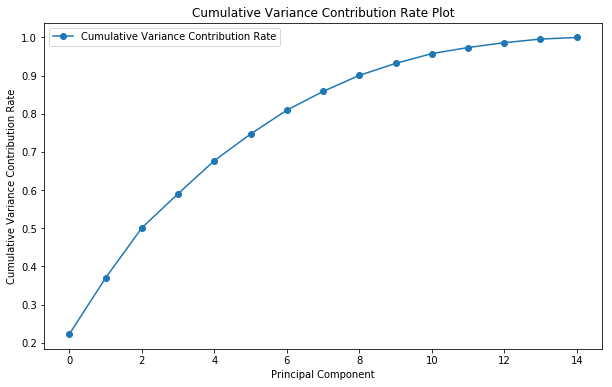

In [32]:
cumulative_variance_ratio = np.cumsum(model.explained_variance_ratio_)
print(cumulative_variance_ratio)
# Plot the cumulative variance contribution rate
plt.figure(figsize=(10, 6))
plt.plot(cumulative_variance_ratio, 'o-', label='Cumulative Variance Contribution Rate')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Contribution Rate')
plt.title('Cumulative Variance Contribution Rate Plot')
plt.legend()
plt.show()

The cumulative variance contribution rate of the first 8 components is greater than 85%.

In [33]:
n_components = 8
X_pca_top = X_pca_df.iloc[:, :n_components] 

The final dataset is obtained.

In [34]:
X_pca_top

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,2.255651,-0.445994,-0.692624,-1.206116,0.767749,0.004496,0.134444,1.913711
1,2.686402,-0.401197,-0.576691,-1.231302,0.710576,0.014401,0.105584,1.942632
2,1.510078,-0.673452,-0.911395,-0.722860,0.477616,-0.102555,0.152594,1.972466
3,0.359981,-0.889297,-1.333569,-0.217473,0.257333,-0.173507,0.172665,1.932981
4,1.980533,-0.576333,-0.682854,-1.062978,0.590743,-0.003618,0.089417,1.984171
...,...,...,...,...,...,...,...,...
6971,0.540615,3.313938,1.179439,0.602597,-0.365906,-1.133744,1.111991,0.660225
6972,-0.956646,3.260871,0.911421,0.940791,-0.593417,-1.195402,1.138607,0.776270
6973,-1.065099,3.200108,0.851238,0.860896,-0.530948,-1.128144,1.081428,0.648842
6974,1.453335,3.549723,1.667940,0.075616,-0.301082,-0.978197,0.989409,0.839368


#### Combine this dataset with `data`
Merge the data by rows using `pd.concat`, ensuring that the original data and principal component scores are aligned.


In [35]:
model_data = pd.concat([data, X_pca_top], axis=1)
model_data.drop(columns=['T_MV', 'PE', 'PB', 'EPS', 'ROE', 'Net_profit', 'Operation_revenue', 
           'TA_turnover', 'MACD', 'RSI', 'OBV', 'CCI', 'ATR', 'WR', 'MI', 'Chage_W'], inplace=True)

In [36]:
model_data

,ts_code,Name,flag,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,000009.SZ,中国宝安,0,2.255651,-0.445994,-0.692624,-1.206116,0.767749,0.004496,0.134444,1.913711
1,000009.SZ,中国宝安,1,2.686402,-0.401197,-0.576691,-1.231302,0.710576,0.014401,0.105584,1.942632
2,000009.SZ,中国宝安,1,1.510078,-0.673452,-0.911395,-0.722860,0.477616,-0.102555,0.152594,1.972466
3,000009.SZ,中国宝安,0,0.359981,-0.889297,-1.333569,-0.217473,0.257333,-0.173507,0.172665,1.932981
4,000009.SZ,中国宝安,0,1.980533,-0.576333,-0.682854,-1.062978,0.590743,-0.003618,0.089417,1.984171
...,...,...,...,...,...,...,...,...,...,...,...
6971,689009.SH,九号公司-WD,1,0.540615,3.313938,1.179439,0.602597,-0.365906,-1.133744,1.111991,0.660225
6972,689009.SH,九号公司-WD,1,-0.956646,3.260871,0.911421,0.940791,-0.593417,-1.195402,1.138607,0.776270
6973,689009.SH,九号公司-WD,0,-1.065099,3.200108,0.851238,0.860896,-0.530948,-1.128144,1.081428,0.648842
6974,689009.SH,九号公司-WD,1,1.453335,3.549723,1.667940,0.075616,-0.301082,-0.978197,0.989409,0.839368


---

## 3. Machine Learning Models

<ul>
<li>Support Vector Machine (SVM)</li>
<li>Logistic Regression (LR)</li>
<li>K-Nearest Neighbors (kNN)</li>
<li>Random Forest (RF)</li>
</ul>


**Use the dataset `model_data`**

### 3.1 Training and Test Sets

Time Set  
- Training data: 2024.8.16 - 2024.11.1
- Testing data: 2024.11.2 - 2024.11.29

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = model_data.iloc[:,3:]
y = model_data.iloc[:,2    ]
X_train_lo, X_test_lo, y_train_lo, y_test_lo = train_test_split(X_pca, y, test_size=0.25, random_state=42)
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(X_pca, y, test_size=0.25, random_state=42)
X_train_RF, X_test_RF, y_train_RF, y_test_RF = train_test_split(X_pca, y, test_size=0.25, random_state=42)
X_train_SVM, X_test_SVM, y_train_SVM, y_test_SVM = train_test_split(X_pca, y, test_size=0.25, random_state=42)

### 3.2 Support Vector Machine (SVM)

In [39]:
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC

Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best parameters found:  {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.5631
Precision: 0.5657
Recall: 0.7000
F1 Score: 0.6257


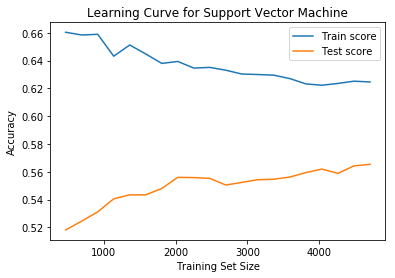

In [40]:
# Define a grid of hyperparameters for SVM
param_grid_SVM = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Type of kernel function
    'gamma': ['scale', 'auto'], # Kernel coefficient 0.1, 1, 10
}

# Initialize the SVM classifier
svm = SVC(random_state=42)

# Perform hyperparameter tuning using GridSearchCV
grid_search_SVM = GridSearchCV(svm, param_grid_SVM, cv=10, n_jobs=-1, verbose=1)
grid_search_SVM.fit(X_train_SVM, y_train_SVM)

# Print the best parameters found
print("Best parameters found: ", grid_search_SVM.best_params_)

# Train the SVM model with the best parameters
best_svm = grid_search_SVM.best_estimator_

# Evaluate the model on the test set
y_pred_SVM = best_svm.predict(X_test_SVM)

# Calculate accuracy
accuracy_SVM = accuracy_score(y_test_SVM, y_pred_SVM)
print(f"Accuracy: {accuracy_SVM:.4f}")

# Calculate precision
precision_SVM = precision_score(y_test_SVM, y_pred_SVM, average='binary') 
print(f"Precision: {precision_SVM:.4f}")

# Calculate recall
recall_SVM = recall_score(y_test_SVM, y_pred_SVM, average='binary') 
print(f"Recall: {recall_SVM:.4f}")

# Calculate the F1 score (harmonic mean of precision and recall)
f1_SVM = f1_score(y_test_SVM, y_pred_SVM, average='binary')
print(f"F1 Score: {f1_SVM:.4f}")

# Plot the learning curve
train_sizes_SVM, train_scores_SVM, test_scores_SVM = learning_curve(
    best_svm, X_train_SVM, y_train_SVM, cv=10, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 20))

# Plot training and validation errors
plt.plot(train_sizes_SVM, np.mean(train_scores_SVM, axis=1), label="Train score")
plt.plot(train_sizes_SVM, np.mean(test_scores_SVM, axis=1), label="Test score")
plt.title("Learning Curve for Support Vector Machine")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

### 3.3 Logistic Regression (LR)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer, confusion_matrix
from sklearn.preprocessing import StandardScaler

Fitting 10 folds for each of 90 candidates, totalling 900 fits


/usr/local/lib64/python3.6/site-packages/sklearn/model_selection/_search.py:925: UserWarning: One or more of the test scores are non-finite: [       nan 0.48604717 0.51395283        nan        nan 0.53020704
 0.52810489 0.53020704 0.53020704 0.53001584        nan        nan
        nan        nan        nan        nan 0.51376855 0.51587071
        nan        nan 0.53421905 0.53383774 0.53421905 0.53421905
 0.53421905        nan        nan        nan        nan        nan
        nan 0.53880213 0.53708311        nan        nan 0.53784464
 0.53727139 0.53765344 0.53746223 0.53765344        nan        nan
        nan        nan        nan        nan 0.53727103 0.53727139
        nan        nan 0.53669705 0.53669705 0.53669705 0.53669705
 0.53669705        nan        nan        nan        nan        nan
        nan 0.5361238  0.5361238         nan        nan 0.5359326
 0.5359326  0.5359326  0.5359326  0.5359326         nan        nan
        nan        nan        nan        nan 0.5361238  

Best Hyperparameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy: 0.5298
Precision: 0.5408
Recall: 0.6549
F1 Score: 0.5924


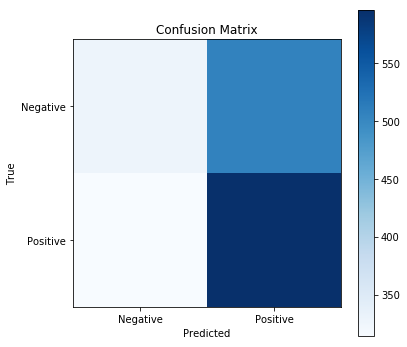

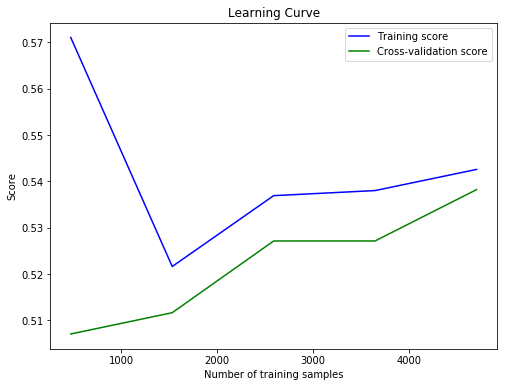

Cross-validation Accuracy: 0.5388 ± 0.0090


In [42]:
# 1. Model building using Logistic Regression
logreg_lo = LogisticRegression(max_iter=1000)

# 2. Grid search to find optimal hyperparameters
param_grid_lo = {
    'C': np.logspace(-3, 2, 6),  # A more detailed range for regularization parameter
    'penalty': ['l1', 'l2', 'elasticnet'],  
    'solver': ['lbfgs', 'liblinear', 'saga', 'newton-cg', 'sag'] 
}

# Define multi-metric scoring
scoring_lo = {
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score)
}

# Create the grid search object, set refit parameter to 'roc_auc', indicating ROC AUC as the refitting metric
grid_search_lo = GridSearchCV(estimator=logreg_lo, param_grid=param_grid_lo, cv=10, 
                              scoring=scoring_lo, refit='roc_auc', n_jobs=-1, verbose=1)

# Fit the grid search object
grid_search_lo.fit(X_train_lo, y_train_lo)

# Output the best parameters
print("Best Hyperparameters:", grid_search_lo.best_params_)

# 3. Train the model with the best hyperparameters
best_logreg_lo = grid_search_lo.best_estimator_

# 4. Make predictions on the test set
y_pred_lo = best_logreg_lo.predict(X_test_lo)

# 5. Evaluate model performance: accuracy, precision, recall
accuracy_lo = accuracy_score(y_test_lo, y_pred_lo)
precision_lo = precision_score(y_test_lo, y_pred_lo)
recall_lo = recall_score(y_test_lo, y_pred_lo)
f1_lo = f1_score(y_test_lo, y_pred_lo, average='binary')

print(f"Accuracy: {accuracy_lo:.4f}")
print(f"Precision: {precision_lo:.4f}")
print(f"Recall: {recall_lo:.4f}")
print(f"F1 Score: {f1_lo:.4f}")

# 6. Plot the confusion matrix
cm_lo = confusion_matrix(y_test_lo, y_pred_lo)
plt.figure(figsize=(6, 6))
plt.imshow(cm_lo, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(2), ['Negative', 'Positive'])
plt.yticks(np.arange(2), ['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 7. Plot the learning curve
train_sizes_lo, train_scores_lo, test_scores_lo = learning_curve(best_logreg_lo, X_train_lo, y_train_lo, cv=10)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes_lo, np.mean(train_scores_lo, axis=1), label='Training score', color='blue')
plt.plot(train_sizes_lo, np.mean(test_scores_lo, axis=1), label='Cross-validation score', color='green')
plt.xlabel('Number of training samples')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend()
plt.show()

# 8. Ten-fold cross-validation
cv_scores_lo = cross_val_score(best_logreg_lo, X_train_lo, y_train_lo, cv=10, scoring='accuracy')
print(f"Cross-validation Accuracy: {np.mean(cv_scores_lo):.4f} ± {np.std(cv_scores_lo):.4f}")

### 3.4 K-Nearest Neighbors (kNN)

In [43]:
from sklearn.neighbors import KNeighborsClassifier

Fitting 10 folds for each of 480 candidates, totalling 4800 fits
Best parameters found:  {'metric': 'minkowski', 'n_neighbors': 21, 'p': 3, 'weights': 'uniform'}
Accuracy: 0.5688
Precision: 0.5813
Recall: 0.6209
F1 Score: 0.6004


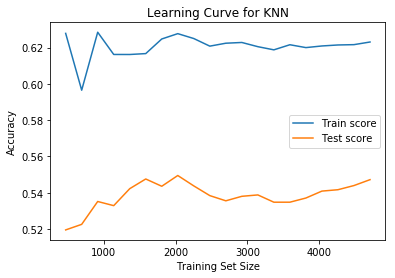

In [44]:
# Grid search for hyperparameter tuning
param_grid_KNN = {
    'n_neighbors': np.arange(1, 31, 2),  # Odd numbers from 1 to 30 for a more detailed range
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan', 'chebyshev'],
    'p': np.arange(1, 5)  # More options for p values
}

knn_KNN = KNeighborsClassifier()

# Perform hyperparameter tuning using GridSearchCV
grid_search_KNN = GridSearchCV(knn_KNN, param_grid_KNN, cv=10, n_jobs=-1, verbose=1)
grid_search_KNN.fit(X_train_KNN, y_train_KNN)

# Output the best parameters found
print("Best parameters found: ", grid_search_KNN.best_params_)

# Train the KNN model with the best parameters
best_knn_KNN = grid_search_KNN.best_estimator_

# Evaluate the model on the test set
y_pred_KNN = best_knn_KNN.predict(X_test_KNN)

# Calculate accuracy
accuracy_KNN = accuracy_score(y_test_KNN, y_pred_KNN)
print(f"Accuracy: {accuracy_KNN:.4f}")

# Calculate precision
precision_KNN = precision_score(y_test_KNN, y_pred_KNN, average='binary')

print(f"Precision: {precision_KNN:.4f}")

# Calculate recall
recall_KNN = recall_score(y_test_KNN, y_pred_KNN, average='binary')

print(f"Recall: {recall_KNN:.4f}")

# Calculate the F1 score (harmonic mean of precision and recall)
f1_KNN = f1_score(y_test_KNN, y_pred_KNN, average='binary')

print(f"F1 Score: {f1_KNN:.4f}")

# Plot the learning curve
train_sizes_KNN, train_scores_KNN, test_scores_KNN = learning_curve(best_knn_KNN, X_train_KNN, y_train_KNN, cv=10, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 20))

plt.plot(train_sizes_KNN, np.mean(train_scores_KNN, axis=1), label="Train score")
plt.plot(train_sizes_KNN, np.mean(test_scores_KNN, axis=1), label="Test score")
plt.title("Learning Curve for KNN")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

### 3.5 Random Forest  (RF)

In [45]:
from sklearn.ensemble import RandomForestClassifier

Fitting 10 folds for each of 324 candidates, totalling 3240 fits
Best parameters found:  {'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Accuracy: 0.5671
Precision: 0.5735
Recall: 0.6648
F1 Score: 0.6158


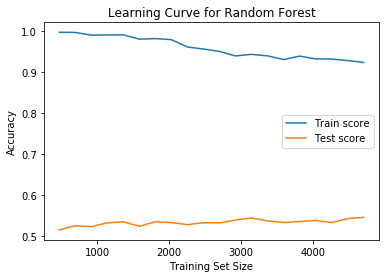

In [46]:
# Grid search for hyperparameter tuning
param_grid_RF = {
    'n_estimators': [100, 200, 300],  # Options for the number of trees
    'max_depth': [10, 20, None],  # Options for maximum depth, including no limit
    'min_samples_split': [2, 5, 10],  # Expanded options for minimum samples for node splitting
    'min_samples_leaf': [1, 2, 4],  # Increased options for minimum samples per leaf node
    'max_features': ['sqrt', 'log2'],  # Options for feature selection
    'bootstrap': [True, False],  # Whether to use bootstrapping or not
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Perform hyperparameter tuning using GridSearchCV
grid_search_RF = GridSearchCV(rf, param_grid_RF, cv=10, n_jobs=-1, verbose=1)
grid_search_RF.fit(X_train_RF, y_train_RF)

# Output the best parameters found
print("Best parameters found: ", grid_search_RF.best_params_)

# Train the Random Forest model with the best parameters
best_rf = grid_search_RF.best_estimator_

# Evaluate the model on the test set
y_pred_RF = best_rf.predict(X_test_RF)

# Calculate accuracy
accuracy_RF = accuracy_score(y_test_RF, y_pred_RF)
print(f"Accuracy: {accuracy_RF:.4f}")

# Calculate precision
precision_RF = precision_score(y_test_RF, y_pred_RF, average='binary')
print(f"Precision: {precision_RF:.4f}")

# Calculate recall
recall_RF = recall_score(y_test_RF, y_pred_RF, average='binary')
print(f"Recall: {recall_RF:.4f}")

# Calculate the F1 score (harmonic mean of precision and recall)
f1_RF = f1_score(y_test_RF, y_pred_RF, average='binary')
print(f"F1 Score: {f1_RF:.4f}")

# Plot the learning curve
train_sizes_RF, train_scores_RF, test_scores_RF = learning_curve(
    best_rf, X_train_RF, y_train_RF, cv=10, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 20))

# Plot training and validation errors
plt.plot(train_sizes_RF, np.mean(train_scores_RF, axis=1), label="Train score")
plt.plot(train_sizes_RF, np.mean(test_scores_RF, axis=1), label="Test score")
plt.title("Learning Curve for Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.show()

---

## 4. Model Evaluation Summary
Evaluate the model's predictive performance using metrics such as accuracy, precision, and recall.

In [47]:
performance_dict = {
    'Model': ['SVM', 'LR', 'kNN','RF'],
    'Accuracy': [accuracy_SVM, accuracy_lo,accuracy_KNN, accuracy_RF],
    'Precision': [precision_SVM, precision_lo, precision_KNN, precision_RF],
    'Recall': [recall_SVM, recall_lo, recall_KNN, recall_RF],
    'F1 score': [f1_SVM, f1_lo, f1_KNN, f1_RF],
}

performance_df = pd.DataFrame(performance_dict)

performance_df = performance_df.set_index('Model')

performance_df

,Accuracy,Precision,Recall,F1 score
Model,,,,
SVM,0.563073,0.565719,0.700000,0.625737
LR,0.529817,0.540835,0.654945,0.592445
kNN,0.568807,0.581276,0.620879,0.600425
RF,0.567087,0.573460,0.664835,0.615776


---

## 5. Constructing a Quantitative Strategy

### 5.1 Quantitative Trading Strategy

#### Strategy Overview
This strategy aims to predict the future price trends of the CSI 500 constituent stocks through a quantitative model and make trading decisions accordingly. The strategy uses a machine learning model to score stocks and decides to buy or sell based on the scoring results.

Here are the specific details of the strategy:

1. **Stock Pool Selection**:
   - Select stocks that have been filtered from the CSI 500 constituents as the trading objects.

2. **Capital Management**:
   - The initial cash is set at 10,000 yuan, and the cash balance and portfolio value are updated after each trade.

3. **Trading Rules**:
   - A fixed number of 10 shares are bought in each transaction, with a trading frequency of weekly rebalancing.
   - If the model predicts that a stock will perform well in the future (signal is 1), then buy that stock; if there is a position and the model predicts that the stock will perform poorly in the future (signal is 0), then sell that stock.

5. **Position Management**:
   - The quantity and cost price of the held stocks are recorded in the `positions` dictionary for tracking and management.

6. **Trade Execution**:
   - Go through each trading day and execute buy or sell operations according to the model's signals and current stock prices.
   - When buying, deduct the corresponding stock purchase costs from the cash and record the position information.
   - When selling, add the proceeds from the sale back to the cash and remove the corresponding stock from the position.


### 5.2 Generate Trading Signals Using the Trained Model for Predictions

The trading signals obtained from the predictions include weekly data from November 8, 2024, to November 29, 2024.

In [48]:
trade_dates = ['20241108', '20241115', '20241122', '20241129']

- SVM

In [49]:
df_pred_SVM = pd.DataFrame(y_pred_SVM.reshape(-1, 4), columns=trade_dates)
df_pred_SVM['ts_code'] = stock_selected_code
df_pred_SVM = df_pred_SVM.set_index('ts_code')
df_pred_SVM

,20241108,20241115,20241122,20241129
ts_code,,,,
000009.SZ,0,1,1,1
000021.SZ,1,0,0,1
000027.SZ,0,0,1,0
000031.SZ,1,1,0,0
000032.SZ,0,0,1,0
...,...,...,...,...
688777.SH,0,1,1,1
688778.SH,0,1,0,1
688779.SH,0,1,0,0


- LR

In [50]:
df_pred_lo = pd.DataFrame(y_pred_lo.reshape(-1, 4), columns=trade_dates)
df_pred_lo['ts_code'] = stock_selected_code 
df_pred_lo = df_pred_lo.set_index('ts_code')

- kNN

In [51]:
df_pred_KNN = pd.DataFrame(y_pred_KNN.reshape(-1, 4), columns=trade_dates)
df_pred_KNN['ts_code'] = stock_selected_code
df_pred_KNN = df_pred_KNN.set_index('ts_code')

- RF

In [52]:
df_pred_RF = pd.DataFrame(y_pred_RF.reshape(-1, 4), columns=trade_dates)
df_pred_RF['ts_code'] = stock_selected_code
df_pred_RF = df_pred_RF.set_index('ts_code')

### 5.3 Acquire Trading Data

Import the daily trading data of the filtered stocks.

In [53]:
# Store data for all stocks and dates
market_data = pd.DataFrame()

stocks = stock_selected_code

# Iterate through each date to get data for each stock
for date in trade_dates:
    for stock in stocks:
        # Get data for a single day
        df = pro.daily(ts_code=stock, trade_date=date)
        # Add the data to the overall DataFrame
        market_data = pd.concat([market_data, df], ignore_index=True)

# Print the result
market_data

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,000009.SZ,20241108,10.76,10.82,10.48,10.48,10.58,-0.10,-0.9452,540150.65,573185.096
1,000021.SZ,20241108,21.01,22.08,21.01,21.28,20.85,0.43,2.0624,1445170.87,3115172.327
2,000027.SZ,20241108,6.99,7.13,6.82,6.86,6.93,-0.07,-1.0101,587404.44,409449.529
3,000031.SZ,20241108,3.66,3.66,3.40,3.41,3.59,-0.18,-5.0139,415029.84,144134.671
4,000032.SZ,20241108,20.02,21.20,20.01,20.13,19.66,0.47,2.3906,765301.90,1567199.728
...,...,...,...,...,...,...,...,...,...,...,...
1738,688777.SH,20241129,46.30,49.13,46.11,48.46,46.45,2.01,4.3272,176158.20,843044.644
1739,688778.SH,20241129,47.36,51.37,47.36,49.48,47.60,1.88,3.9496,81720.60,404511.213
1740,688779.SH,20241129,6.07,6.13,5.93,6.05,6.04,0.01,0.1656,269415.29,162844.306
1741,688819.SH,20241129,28.50,29.18,28.23,28.90,28.45,0.45,1.5817,28872.19,83061.501


In [54]:
market_data.to_csv('market_data.csv', index=False)

In [55]:
df = pd.read_csv("market_data.csv")

In [56]:
specific_dates = ['20241108', '20241115', '20241122', '20241129']
df_specific = df[df['trade_date'].isin(specific_dates)]

trade_data = df_specific.pivot_table(index='ts_code', columns='trade_date', values='close')

trade_data.set_axis(['20241108', '20241115', '20241122', '20241129'], axis=1, inplace=True)

trade_data

,20241108,20241115,20241122,20241129
ts_code,,,,
000009.SZ,10.48,9.84,9.35,9.86
000021.SZ,21.28,20.35,19.72,20.16
000027.SZ,6.86,6.62,6.52,6.62
000031.SZ,3.41,3.10,3.05,3.29
000032.SZ,20.13,19.53,18.88,18.66
...,...,...,...,...
688777.SH,51.09,49.28,47.09,48.46
688778.SH,55.88,50.44,47.86,49.48
688779.SH,6.34,6.14,6.07,6.05


In [57]:
print(trade_data.isnull().sum())

20241108    0
20241115    0
20241122    0
20241129    1
dtype: int64


In [58]:
trade_data.iloc[343,3] = 93

### 5.4 Strategy Establishment

When the trading signal in the `df_pred` table is 1 for a particular stock, it indicates a positive outlook for the stock's future performance, hence the stock with a signal of 1 will be bought. At the next time point, the holdings will be adjusted according to the latest trading signals: if a stock's signal changes from 1 to 0, the stock will be sold; if a stock's signal changes from 0 to 1, the stock will be bought; if the stock's signal remains 1, the current holding will be maintained. The initial capital is set at 100,000 yuan.

**Explanation of the function definition:**

- `trading_strategy(df_pred, trade_data, stock_selected_code, specific_dates, initial_cash=100000):` defines a function named `trading_strategy` that takes five parameters:
  - `df_pred`: A DataFrame containing the trading signals for the selected stocks.
  - `trade_data`: A DataFrame containing the closing prices of the selected stocks.
  - `stock_selected_code`: A list of stock codes for which trading signals are generated.
  - `specific_dates`: A list of specific dates for which the trading signals are applicable.
  - `initial_cash`: The initial amount of cash available for trading, defaulting to 100,000.

In [59]:
def trading_strategy(df_pred, trade_data, stock_selected_code, specific_dates, initial_cash=100000):
    cash = initial_cash
    positions = {}  # Store the stock positions and cost prices
    portfolio_value = initial_cash

    # Iterate through each trading day
    for date in specific_dates:
        # Iterate through each stock
        for ts_code in stock_selected_code:  # Skip the date column
            signal = df_pred.loc[ts_code, date]
            current_price = trade_data.loc[ts_code, date]
            
            if signal == 1:
                if ts_code not in positions:
                    # Buy the stock
                    if cash > 0:
                        shares = 10  # Assume buying 10 shares each time
                        cash -= shares * current_price
                        positions[ts_code] = {'shares': shares, 'cost': current_price}
                        print(date, ': Buy', shares, ts_code, '\n', cash)
                
                else:
                    # Hold the position
                    pass
            
            elif signal == 0 and ts_code in positions:
                # Sell the stock
                cash += positions[ts_code]['shares'] * current_price
                print(date, ': Sell', positions[ts_code]['shares'], ts_code, '\n', cash)
                del positions[ts_code]

        # Update the portfolio value
        portfolio_value = cash
        for ts_code, info in positions.items():
            portfolio_value += info['shares'] * current_price

    # Print the final portfolio value
    print(f'Final Portfolio Value: {portfolio_value}')
    return portfolio_value

**Explanation of the function definition:**

- `evaluate_strategies(trading_strategies, trade_data, stock_selected_code, specific_dates, initial_cash=100000):` defines a function named `evaluate_strategies` that takes five parameters:
  - `trading_strategies`: A list of strings, where each string is the name of a variable containing the trading signals for a specific strategy.
  - `trade_data`: A DataFrame containing the closing prices of the selected stocks.
  - `stock_selected_code`: A list of stock codes for which trading signals are generated.
  - `specific_dates`: A list of specific dates for which the trading signals are applicable.
  - `initial_cash`: The initial amount of cash available for trading, defaulting to 100,000.

The function evaluates multiple trading strategies and returns a summary of their performance

In [60]:
def evaluate_strategies(trading_strategies, trade_data, stock_selected_code, specific_dates, initial_cash=100000):
    # Store the final portfolio value and initial cash for each strategy
    results = {}

    for strategy in trading_strategies:
        # Get the corresponding DataFrame based on the strategy name
        df_pred = eval(strategy)  # Use eval to get the variable
        final_value = trading_strategy(df_pred, trade_data, stock_selected_code, specific_dates)
        
        # Store the results in a dictionary, including the initial cash
        results[strategy] = {'Final Portfolio Value': final_value, 'Initial Cash': initial_cash}

    # Create a DataFrame to display the results
    results_df = pd.DataFrame.from_dict(results, orient='index')
    
    return results_df.reset_index().rename(columns={'index': 'Strategy'})

**Calling a function**

In [61]:
strategies = ['df_pred_SVM', 'df_pred_lo', 'df_pred_KNN', 'df_pred_RF']

In [62]:
trading_strategies = ['df_pred_SVM', 'df_pred_lo', 'df_pred_KNN', 'df_pred_RF']
final_results_df = evaluate_strategies(trading_strategies, trade_data, stock_selected_code, specific_dates)
final_results_df['Return (%)'] = ((final_results_df['Final Portfolio Value'] - final_results_df['Initial Cash']) / final_results_df['Initial Cash']) * 100

print(final_results_df)

20241108 : Buy 10 000021.SZ 
 99787.2
20241108 : Buy 10 000031.SZ 
 99753.09999999999
20241108 : Buy 10 000039.SZ 
 99665.79999999999
20241108 : Buy 10 000050.SZ 
 99570.19999999998
20241108 : Buy 10 000060.SZ 
 99518.39999999998
20241108 : Buy 10 000066.SZ 
 99294.79999999997
20241108 : Buy 10 000155.SZ 
 99176.79999999997
20241108 : Buy 10 000400.SZ 
 98860.59999999998
20241108 : Buy 10 000423.SZ 
 98257.69999999998
20241108 : Buy 10 000513.SZ 
 97875.79999999999
20241108 : Buy 10 000537.SZ 
 97775.49999999999
20241108 : Buy 10 000539.SZ 
 97726.69999999998
20241108 : Buy 10 000559.SZ 
 97654.09999999998
20241108 : Buy 10 000563.SZ 
 97609.49999999997
20241108 : Buy 10 000598.SZ 
 97535.49999999997
20241108 : Buy 10 000629.SZ 
 97504.69999999997
20241108 : Buy 10 000636.SZ 
 97338.79999999997
20241108 : Buy 10 000683.SZ 
 97271.79999999997
20241108 : Buy 10 000703.SZ 
 97206.09999999998
20241108 : Buy 10 000729.SZ 
 97099.59999999998
20241108 : Buy 10 000750.SZ 
 97046.89999999998
20

### 5.5 Rresults

In [63]:
final_results_df

,Strategy,Final Portfolio Value,Initial Cash,Return (%)
0,df_pred_SVM,160817.8,100000,60.8178
1,df_pred_lo,151258.2,100000,51.2582
2,df_pred_KNN,144253.6,100000,44.2536
3,df_pred_RF,152064.3,100000,52.0643


## 6 Comparative Analysis of Results


### 6.1 Model Results Comparison

In [64]:
final_results_df['Strategy'] = ['Support Vector Machine', 'Logistic Regression', 'K-nearest Neighbor Classification', 'Random Forest']
final_results_df.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},  
    {'selector': 'td', 'props': [('text-align', 'left')]}       
])

,Strategy,Final Portfolio Value,Initial Cash,Return (%)
0,Support Vector Machine,160817.800000,100000,60.817800
1,Logistic Regression,151258.200000,100000,51.258200
2,K-nearest Neighbor Classification,144253.600000,100000,44.253600
3,Random Forest,152064.300000,100000,52.064300


In [65]:
strategy_and_return = final_results_df[['Strategy', 'Return (%)']]
performance_data = performance_df[['Accuracy', 'Precision', 'Recall', 'F1 score']].reset_index(drop=True)

In [66]:
Model_Performance = pd.concat([strategy_and_return, performance_data], axis=1)

In [67]:
Model_Performance.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},  
    {'selector': 'td', 'props': [('text-align', 'left')]}       
])

,Strategy,Return (%),Accuracy,Precision,Recall,F1 score
0,Support Vector Machine,60.817800,0.563073,0.565719,0.700000,0.625737
1,Logistic Regression,51.258200,0.529817,0.540835,0.654945,0.592445
2,K-nearest Neighbor Classification,44.253600,0.568807,0.581276,0.620879,0.600425
3,Random Forest,52.064300,0.567087,0.573460,0.664835,0.615776


### 6.2 Comparison of Returns with the CSI 500 Index

Get the daily trading data of the CSI 500 index

In [68]:
Data_CSI500 = pro.index_daily(ts_code='399905.SZ', start_date='20241101', end_date='20241129')

In [69]:
Data_CSI500.head()

,ts_code,trade_date,close,open,high,low,pre_close,change,pct_chg,vol,amount
0,399905.SZ,20241129,5851.9385,5748.1665,5899.8730,5736.4093,5757.5965,94.3420,1.6386,204255544.0,243571196.9
1,399905.SZ,20241128,5757.5965,5802.7970,5826.4882,5749.2874,5804.9368,-47.3403,-0.8155,172183537.0,204358289.2
2,399905.SZ,20241127,5804.9368,5669.5549,5805.6350,5603.9955,5690.4792,114.4576,2.0114,175313302.0,204528721.6
3,399905.SZ,20241126,5690.4792,5727.3734,5773.3559,5688.5764,5735.6493,-45.1701,-0.7875,147562865.0,170186745.3
4,399905.SZ,20241125,5735.6493,5754.5473,5774.8166,5662.0946,5750.2457,-14.5964,-0.2538,186005060.0,215261571.7


In [70]:
CSI500_return = ((Data_CSI500['close'].iloc[-1] - Data_CSI500['close'].iloc[0]) / Data_CSI500['close'].iloc[0])*100
print('The total return of the CSI 500 Index from November 1, 2024 to November 29, 2024 was:',CSI500_return,"%")

The total return of the CSI 500 Index from November 1, 2024 to November 29, 2024 was: -0.3437630111799669 %


In [71]:
returns = final_results_df[['Strategy', 'Return (%)']]
returns.loc[len(returns)] = ['CSI 500 index', CSI500_return]
returns.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},  
    {'selector': 'td', 'props': [('text-align', 'left')]}       
])

/usr/local/lib64/python3.6/site-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


,Strategy,Return (%)
0,Support Vector Machine,60.817800
1,Logistic Regression,51.258200
2,K-nearest Neighbor Classification,44.253600
3,Random Forest,52.064300
4,CSI 500 index,-0.343763
